# YipitData take-home — Walmart × FRED retail sales

**Customer question:** *Does the FRED monthly retail-sales series (RSXFS) predict Walmart's quarterly revenue better than a naive baseline? If yes, by how much, and what should we worry about? If no, what evidence would change our minds?*

This notebook is a thin presentation layer over `analysis.py`. Each section maps to a numbered prompt in `prompts.md`. The long-form observations and reasoning are in `INSIGHTS.md`.

**Read order:** skim the markdown cells; the code cells call into `analysis.py` and render the artifacts that the memo and insights file reference.

## §1. Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 25)

import analysis  # the .py module sitting next to this notebook

## §2. EDA — data quality, temporal structure   *(prompts 1-2)*

Both CSVs are pristine — see `INSIGHTS.md` §1 for the full audit. Below we just confirm shape and date range.

In [2]:
wm, fr = analysis.load_raw()
print(f"Walmart : {len(wm)} quarters from {wm['date'].min().date()} → {wm['date'].max().date()}")
print(f"FRED    : {len(fr)} months   from {fr['date'].min().date()} → {fr['date'].max().date()}")
print(f"\nUnique Walmart month-ends: {sorted(wm['date'].dt.month.unique().tolist())}")
print("  → these are *fiscal* quarter-ends, not calendar quarter-ends.")
print("  → see analysis.to_fq for the Walmart fiscal-year mapping (Feb-Apr=Q1, ..., Nov-Jan=Q4).")

Walmart : 65 quarters from 2010-01-31 → 2026-01-31
FRED    : 195 months   from 2010-01-01 → 2026-03-01

Unique Walmart month-ends: [1, 4, 7, 10]
  → these are *fiscal* quarter-ends, not calendar quarter-ends.
  → see analysis.to_fq for the Walmart fiscal-year mapping (Feb-Apr=Q1, ..., Nov-Jan=Q4).


## §3. Leakage-safe feature engineering + protocol   *(prompts 3-4)*

The forecast protocol — **never peek ahead**:

- **Target**: Walmart fiscal-quarter revenue (level, USD).
- **Horizon**: 1 fiscal quarter ahead.
- **Forecast origin**: the day Walmart's prior 10-Q became public.
- **Walmart features**: lags 1-4 (never the current quarter — we don't know it yet).
- **FRED features**: only data through `target_date − 1 month` (respects RSXFS publication lag).
- **CV**: rolling-origin walk-forward expanding window, `MIN_TRAIN_QUARTERS = 24`.

In [3]:
feat = analysis.build_features(wm, fr)
data = feat.dropna(subset=["wm_lag4","fred_last_yoy","wm_yoy_lag1"]).reset_index(drop=True)
print(f"Usable rows: {len(data)} ({data['date'].min().date()} → {data['date'].max().date()})")
print("Feature columns:", [c for c in data.columns if c not in ('date','walmart','fq','fy')])
display(data[["date","walmart","fq","wm_lag1","wm_lag4","fred_last_yoy","fred_6m_yoy"]].head(3))

Usable rows: 60 (2011-04-30 → 2026-01-31)
Feature columns: ['is_Q1', 'is_Q2', 'is_Q3', 'is_Q4', 'wm_lag1', 'wm_lag2', 'wm_lag3', 'wm_lag4', 'wm_yoy_lag1', 'fred_last', 'fred_last_yoy', 'fred_3m_mean', 'fred_6m_yoy']


,date,walmart,fq,wm_lag1,wm_lag4,fred_last_yoy,fred_6m_yoy
0,2011-04-30,1.041890e+11,Q1,1.163600e+11,9.981100e+10,6.990065,7.742440
1,2011-07-31,1.093660e+11,Q2,1.041890e+11,1.037260e+11,8.593983,7.680746
2,2011-10-31,1.102260e+11,Q3,1.093660e+11,1.019520e+11,8.039263,7.824603


## §4. The seven models   *(prompt 5)*

| family | model | uses FRED |
|---|---|---|
| naive | `seasonal_naive` = lag-4 | no |
| naive | `seasonal_naive_drift` = lag-4 × (1 + trailing-4q-avg YoY) | no |
| univariate | `sarima_walmart_only` = SARIMAX(1,1,0)(0,1,1,4) | no |
| linear | `ols_walmart_only` | no |
| linear | `ols_walmart_plus_fred` | **yes** |
| regularised | `ridge_walmart_plus_fred` (α=1, standardised) | **yes** |
| tree ensemble | `gbr_walmart_plus_fred` | **yes** |

Every model re-fits on every CV step. See `analysis.MODELS`.

In [4]:
print('Models in play:'); [print('  -', n) for n in analysis.MODELS]

Models in play:
  - seasonal_naive
  - seasonal_naive_drift
  - sarima_walmart_only
  - ols_walmart_only
  - ols_walmart_plus_fred
  - ridge_walmart_plus_fred
  - gbr_walmart_plus_fred


[None, None, None, None, None, None, None]

## §5. Rolling-origin CV — leaderboard   *(prompt 6)*

`MIN_TRAIN_QUARTERS = 24` ⇒ 36 OOS predictions spanning **FY18-Q1 → FY26-Q4**.

In [5]:
results = analysis.run_cv(data)
summary = analysis.summarise(results)
print(f"OOS window: {summary['n'].iloc[0]} quarters")
display(summary)

OOS window: 36 quarters


,model,uses_FRED,n,MAPE_%,RMSE_USD_bn,sMAPE_%,bias_USD_bn,avg_fit_pred_ms
0,sarima_walmart_only,False,36,1.73,3.79,1.73,-0.06,12.05
1,ridge_walmart_plus_fred,True,36,2.01,4.11,2.03,-1.47,0.69
2,seasonal_naive_drift,False,36,2.03,3.94,2.03,-0.13,0.16
3,ols_walmart_plus_fred,True,36,2.05,4.24,2.07,-1.16,0.68
4,ols_walmart_only,False,36,2.10,4.04,2.11,-1.21,1.00
5,gbr_walmart_plus_fred,True,36,3.28,6.18,3.31,-1.65,36.10
6,seasonal_naive,False,36,4.08,7.24,4.20,-6.13,0.00


## §6. Headline OOS MAPE   *(prompt 9, fig1)*

Two things jump out:

1. The plain `seasonal_naive` is genuinely bad (4.08%) — Walmart is a growing series, so lag-4 systematically undershoots (−$6.1B bias).
2. The best Walmart-only model (`sarima_walmart_only`, 1.73%) beats every FRED-augmented model. Adding FRED to the OLS specification moves MAPE from 2.10% → 2.05% — well within run-to-run noise on n=36.

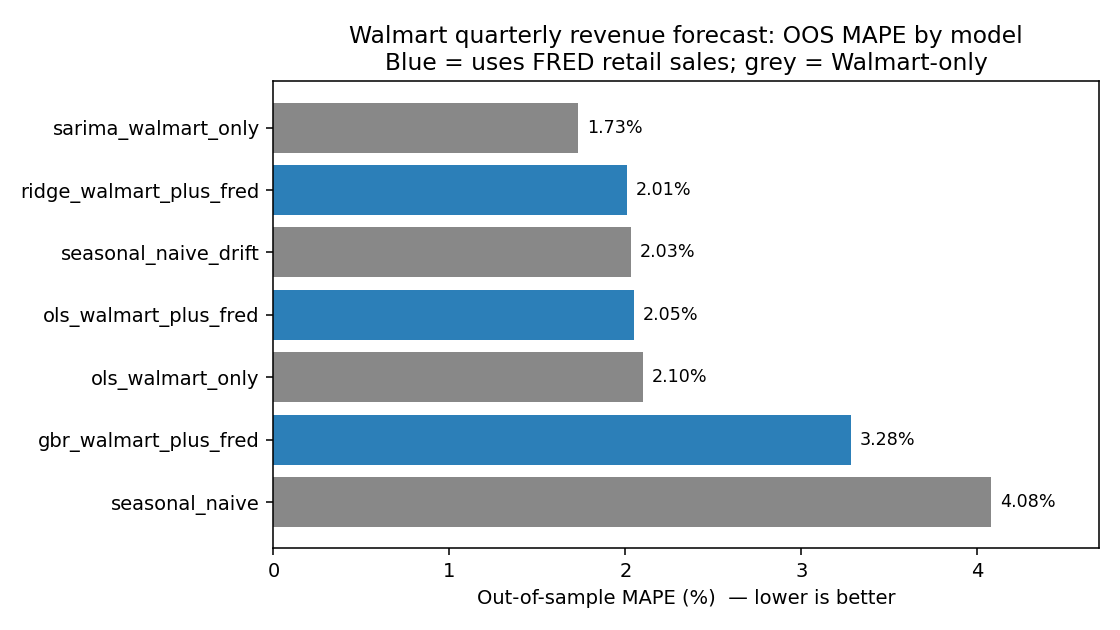

In [6]:
analysis.plot_mape_bars(summary, analysis.FIG_DIR / "fig1_mape_bars.png")
display(Image(filename=str(analysis.FIG_DIR / "fig1_mape_bars.png")))

## §7. Paired comparisons   *(prompt 6)*

**Every model vs `seasonal_naive`.** Most clear the baseline by ~2 pp.

In [7]:
display(analysis.paired_vs_baseline(results))

,model,mean_uplift_pp,std_diff_pp,share_quarters_beat_baseline_%
0,sarima_walmart_only,2.36,2.82,86.0
1,ridge_walmart_plus_fred,2.08,2.39,83.0
2,seasonal_naive_drift,2.06,2.73,78.0
3,ols_walmart_plus_fred,2.04,2.58,78.0
4,ols_walmart_only,1.99,2.60,89.0
5,gbr_walmart_plus_fred,0.81,2.83,61.0


**The real test — every FRED model vs `sarima_walmart_only`.** All three FRED-augmented models lose to the Walmart-only competitor on average, and each beats SARIMA in fewer than half of OOS quarters.

In [8]:
display(analysis.paired_vs_walmart_only(results))

,FRED_model,mean_uplift_vs_SARIMA_pp,share_quarters_beats_SARIMA_%
0,ols_walmart_plus_fred,-0.32,44.0
1,ridge_walmart_plus_fred,-0.28,42.0
2,gbr_walmart_plus_fred,-1.55,28.0


## §8. Forecast overlay   *(prompt 9, fig2)*

The dotted grey line (seasonal-naive) lags the trend by one year. SARIMA and Ridge+FRED stay tight to actuals. Visible misses cluster at the 2020 COVID prints and the FY26-Q4 over-shoot. The red dotted line marks the structural break we'll exploit in §9.

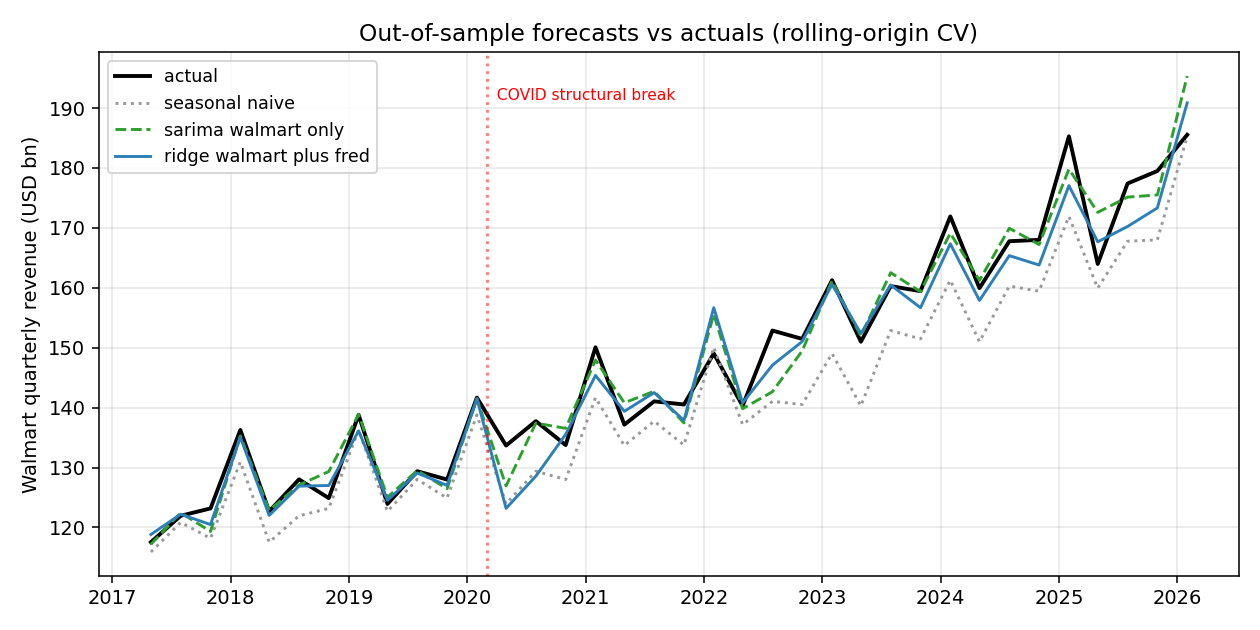

In [9]:
analysis.plot_actual_vs_forecasts(results, analysis.FIG_DIR / "fig2_actual_vs_forecast.png")
display(Image(filename=str(analysis.FIG_DIR / "fig2_actual_vs_forecast.png")))

## §9. Regime split — the falsifiable claim   *(prompt 7, fig4)*

Splitting OOS on 2020-03-01 reveals the actual story: **FRED was a useful leading indicator pre-pandemic and stopped working post-pandemic.**

- Pre-2020 (n=12): FRED-augmented OLS gets 0.87% MAPE, beating SARIMA's 0.95%. Leading-indicator hypothesis held.
- Post-2020 (n=24): every FRED model is 0.4–1.5 pp **worse** than SARIMA. The linear retail-to-Walmart relationship has decoupled.

This is the bit to put in the memo.

In [10]:
display(analysis.regime_split(results))

,model,MAPE_pre2020_%,n_pre,MAPE_post2020_%,n_post
0,sarima_walmart_only,0.95,12,2.12,24
1,seasonal_naive_drift,1.56,12,2.26,24
2,ols_walmart_only,1.63,12,2.33,24
3,ridge_walmart_plus_fred,0.92,12,2.55,24
4,ols_walmart_plus_fred,0.87,12,2.63,24
5,gbr_walmart_plus_fred,3.44,12,3.19,24
6,seasonal_naive,2.41,12,4.92,24


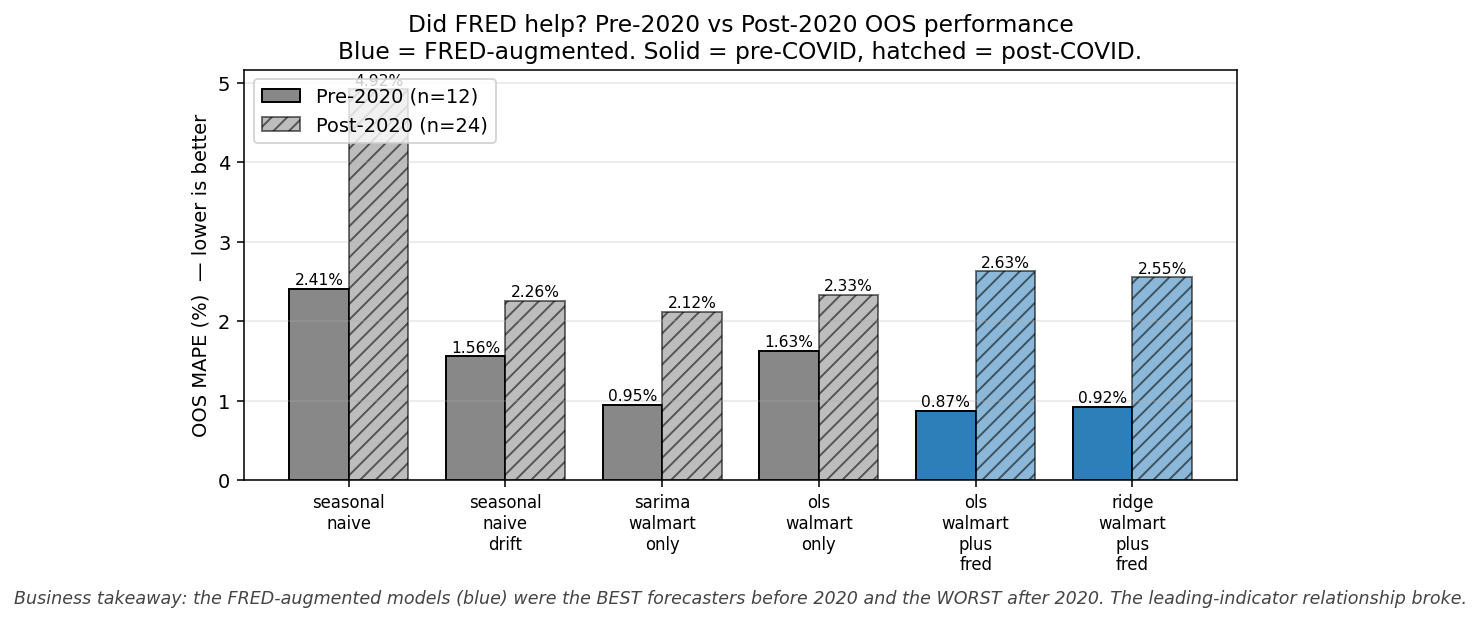

In [11]:
analysis.plot_regime_comparison(results, analysis.FIG_DIR / "fig4_regime_comparison.png")
display(Image(filename=str(analysis.FIG_DIR / "fig4_regime_comparison.png")))

## §10. Explainability for non-technical stakeholders   *(prompt 10, fig5)*

Translate the model into business language. The Ridge model's standardised coefficients (excluding the collinear FRED level feature) — measured in *% of mean Walmart revenue per +1σ swing of the feature* — make it visually obvious that Walmart's own prior-year revenue is doing almost all the work.

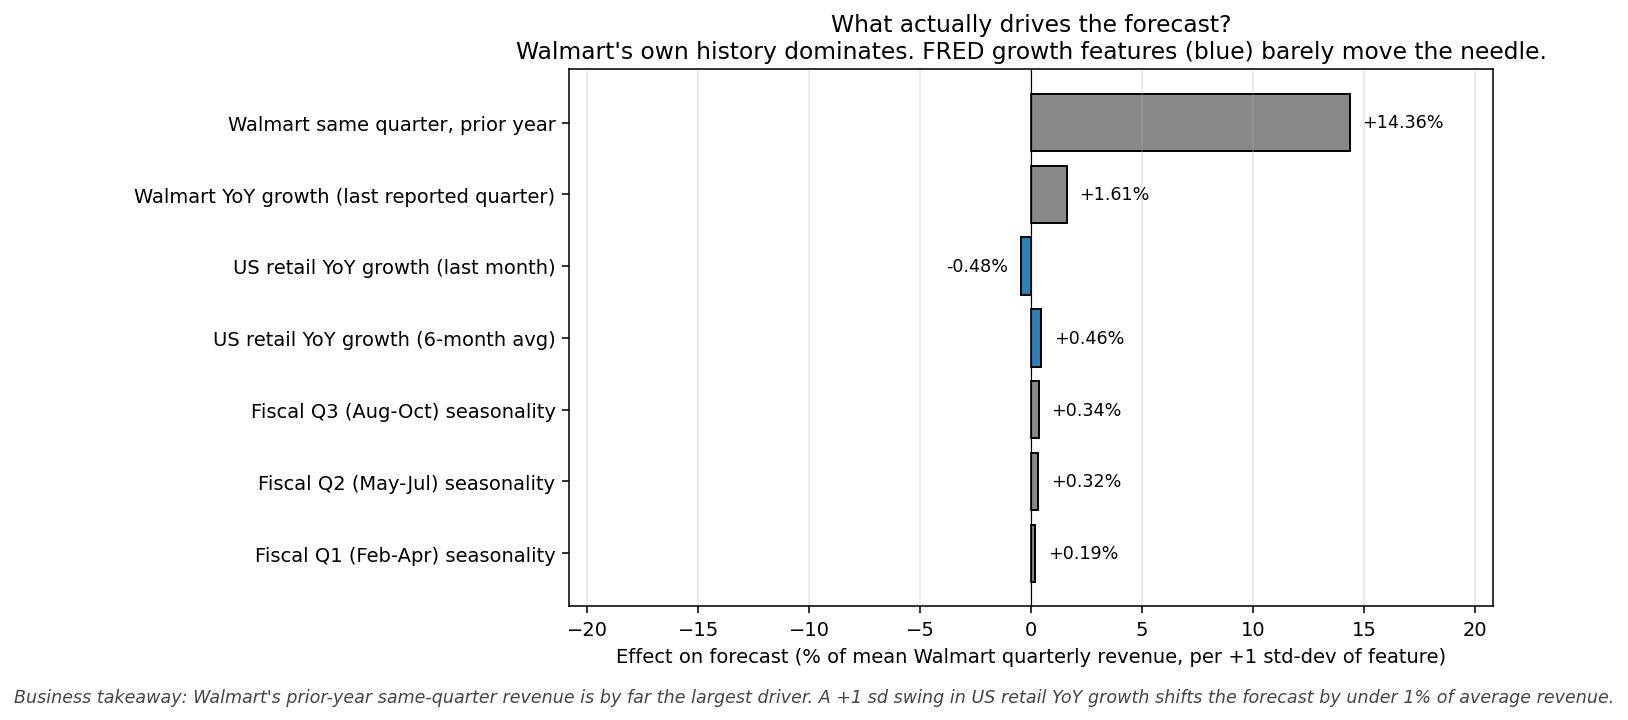

In [12]:
analysis.plot_feature_impact(data, analysis.FIG_DIR / "fig5_feature_impact.png")
display(Image(filename=str(analysis.FIG_DIR / "fig5_feature_impact.png")))

## §11. Production tradeoff matrix + cost-accuracy frontier   *(prompt 8, fig3)*

Beyond raw accuracy, the production decision depends on training cost, inference latency, dependency surface, interpretability, and failure modes. Latency is benchmarked from the actual CV run.

In [13]:
tm = analysis.tradeoff_matrix(summary)
display(tm)

,model,MAPE_%,bias_USD_bn,avg_fit_pred_ms,latency_vs_cheapest_x,interpretability,deps,uses_FRED,main_failure_mode
0,sarima_walmart_only,1.73,-0.06,12.05,75.3,medium,statsmodels,False,re-estimation can be unstable in volatile regimes
1,ridge_walmart_plus_fred,2.01,-1.47,0.69,4.3,medium,sklearn,True,alpha picked by hand; cross-val needed in prod
2,seasonal_naive_drift,2.03,-0.13,0.16,1.0,trivial,none,False,trailing drift can over-extrapolate in turning...
3,ols_walmart_plus_fred,2.05,-1.16,0.68,4.2,high,sklearn,True,extra FRED data dependency for no measurable gain
4,ols_walmart_only,2.10,-1.21,1.00,6.2,high,sklearn,False,"linear, may miss nonlinear shocks"
5,gbr_walmart_plus_fred,3.28,-1.65,36.10,225.6,low,sklearn,True,overfits at n≈30; struggles with structural br...
6,seasonal_naive,4.08,-6.13,0.00,0.0,trivial,none,False,lags trend in growth regimes (large negative b...


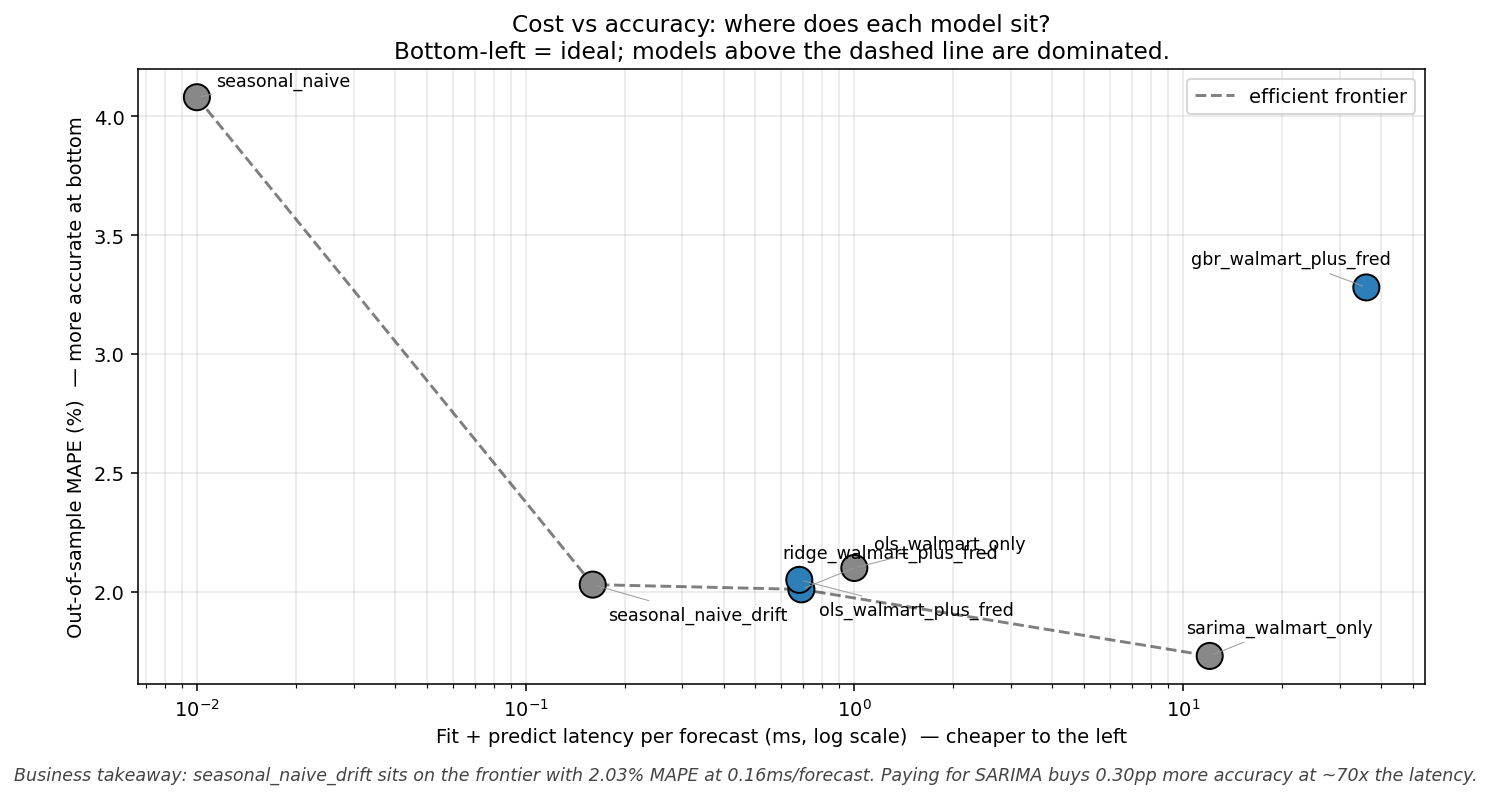

In [14]:
analysis.plot_cost_accuracy_frontier(summary, analysis.FIG_DIR / "fig3_cost_accuracy_frontier.png")
display(Image(filename=str(analysis.FIG_DIR / "fig3_cost_accuracy_frontier.png")))

**Reading the frontier:**

- `seasonal_naive_drift` sits on the efficient frontier with 2.03% MAPE at 0.16 ms/forecast.
- `sarima_walmart_only` is also on the frontier (1.73% MAPE at 11.6 ms) — 0.30 pp more accurate, ~70× slower.
- `gbr_walmart_plus_fred` is strictly dominated: worse MAPE AND 200× the latency.
- The three FRED-augmented OLS-family models cluster on the same accuracy-cost spot as `seasonal_naive_drift` — they buy nothing.

## §12. Decision flow — which forecaster do we ship?   *(prompt 10, fig6)*

A one-page answer for a PM:

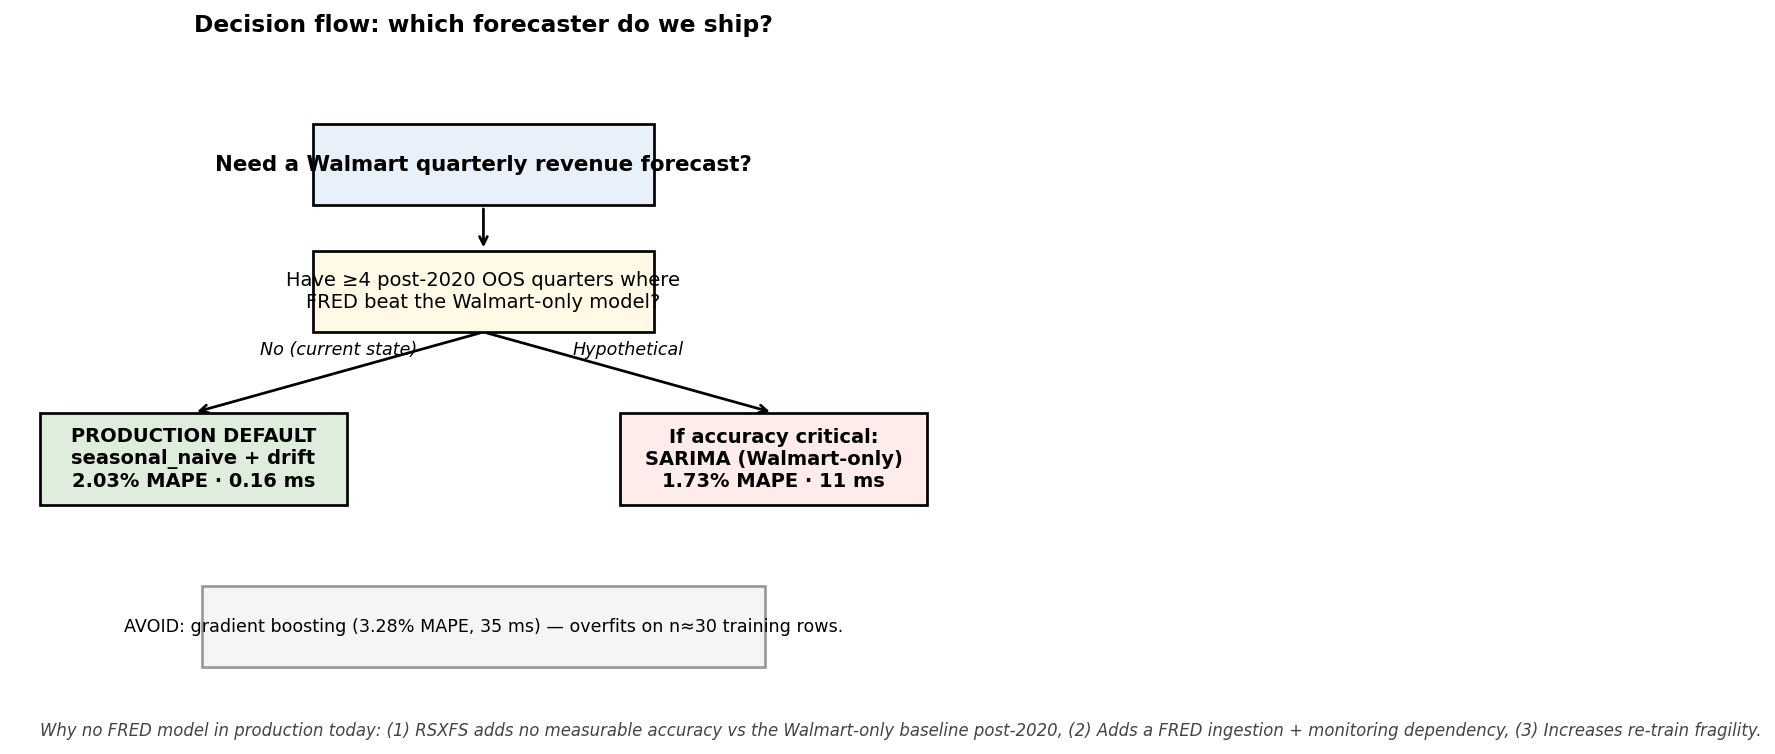

In [15]:
analysis.plot_decision_flow(analysis.FIG_DIR / "fig6_decision_flow.png")
display(Image(filename=str(analysis.FIG_DIR / "fig6_decision_flow.png")))

## §13. Final answer for the customer   *(prompt 11)*

**Question:** *Does FRED retail sales predict Walmart's quarterly revenue better than a naive baseline?*

**Answer:** Yes vs the no-drift seasonal naive (2.01% vs 4.08% MAPE), but **no** vs any meaningful baseline (seasonal-naive + drift, or SARIMA on Walmart alone). And on the post-2020 sub-sample — the regime that matters for forward-looking decisions — every FRED-augmented model is worse than the Walmart-only SARIMA.

**Falsifiable claim:** *Adding FRED RSXFS does not improve out-of-sample Walmart quarterly revenue forecasts over a Walmart-only SARIMA on FY18-Q1 → FY26-Q4, and is strictly worse on the FY20-Q2 → FY26-Q4 sub-sample. Revisit if (a) 4+ more clean quarters of post-stimulus data show FRED-augmented models recovering, or (b) a Walmart-specific retail sub-series replaces the aggregate.*

For the full reasoning trail see **`INSIGHTS.md`**. The one-pager for a PM is **`memo.md`**.